In [65]:
pip install tensorflow_datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 20.7 MB/s  0:00:00m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [tensorflow_datasets]nsorflow_datasets]

[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [66]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow_datasets as tfds
from sklearn.model_selection import train_test_split

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import warnings
warnings.filterwarnings('ignore')

In [63]:
tf.config.list_physical_devices('GPU')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [ ]:
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max"
)

In [176]:
dataset, info = tfds.load('cats_vs_dogs', with_info=True, as_supervised=True)

info

tfds.core.DatasetInfo(
    name='cats_vs_dogs',
    full_name='cats_vs_dogs/4.0.1',
    description="""
    A large set of images of cats and dogs. There are 1738 corrupted images that are dropped.
    """,
    homepage='https://www.microsoft.com/en-us/download/details.aspx?id=54765',
    data_dir='/home/jgaldeano/tensorflow_datasets/cats_vs_dogs/4.0.1',
    file_format=tfrecord,
    download_size=786.67 MiB,
    dataset_size=1.04 GiB,
    features=FeaturesDict({
        'image': Image(shape=(None, None, 3), dtype=uint8),
        'image/filename': Text(shape=(), dtype=string),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=2),
    }),
    supervised_keys=('image', 'label'),
    disable_shuffling=False,
    nondeterministic_order=False,
    splits={
        'train': <SplitInfo num_examples=23262, num_shards=16>,
    },
    citation="""@Inproceedings (Conference){asirra-a-captcha-that-exploits-interest-aligned-manual-image-categorization,
    author = {Elson, Jeremy and D

In [177]:
dataset = dataset['train']

In [178]:
clases = ['cat','dog']

(262, 350, 3)


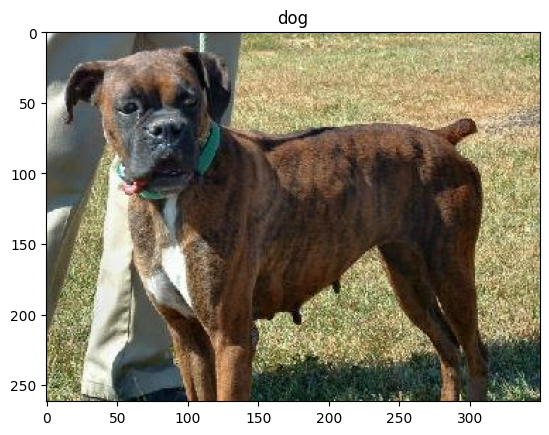

In [179]:
for im, lab in dataset.take(1):
    plt.imshow(im.numpy().astype('uint8'))
    plt.title(clases[lab])
    print(im.shape)
   
   

In [180]:
size = tf.data.experimental.cardinality(dataset).numpy()
size

23262

In [181]:
def resize(image,label):
    image = tf.image.resize(
        image,
        (100,100),
        tf.image.ResizeMethod.BILINEAR
    )
    
    return image, label

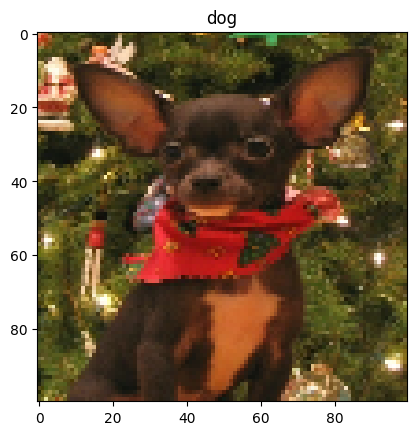

In [182]:
for im, lab in dataset.take(2):
    im_resize,label = resize(im,lab)
    plt.imshow(im_resize.numpy().astype('uint8'))
    plt.title(clases[label])

In [183]:
dataset = dataset.map(resize, num_parallel_calls= tf.data.AUTOTUNE)

In [184]:
dataset = dataset.shuffle(size, reshuffle_each_iteration=False)

In [185]:
train_size = int(size*0.75)

train_ds = dataset.take(train_size)

test_ds = dataset.skip(train_size)

In [186]:
train_ds = (
    train_ds
        .shuffle(1000)
        .cache()
        .batch(8)
        .prefetch(tf.data.AUTOTUNE)
)

test_ds = (
    test_ds
        .cache()
        .batch(8)
        .prefetch(tf.data.AUTOTUNE)
)

2026-07-10 17:49:11.601538: W tensorflow/core/kernels/data/cache_dataset_ops.cc:917] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


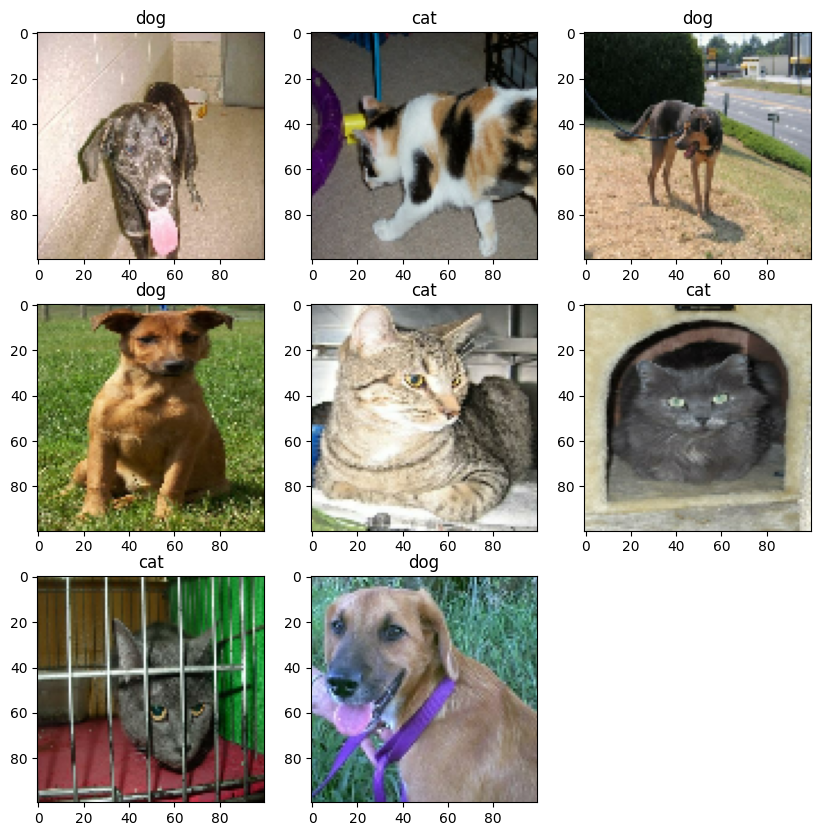

In [187]:
plt.figure(figsize=(10,10))

for im, lab in train_ds.take(1):
    for i in range(8):
        plt.subplot(3,3,i+1)
        plt.imshow(im[i].numpy().astype('uint8'))
        plt.title(clases[lab[i]])

In [170]:
# Inputs

inputs = tf.keras.layers.Input(shape = (64,64,3,))

augm = tf.keras.layers.RandAugment(value_range=(0,255),
                                   num_ops = 3,
                                   factor = 0.25)(inputs)

rees = tf.keras.layers.Rescaling(1/255)(augm)

# conv

x = tf.keras.layers.Conv2D(filters=32,
                           kernel_size=3,
                           padding='same',
                           use_bias=False)(rees)

x = tf.keras.layers.BatchNormalization()(x)

x = tf.keras.layers.ReLU()(x)

x = tf.keras.layers.Conv2D(filters=64,
                           kernel_size=3,
                           padding='same',
                           use_bias=False)(x)

x = tf.keras.layers.BatchNormalization()(x)

x = tf.keras.layers.ReLU()(x)

x = tf.keras.layers.Conv2D(filters=128,
                           kernel_size=3,
                           padding='same',
                           use_bias=False)(x)

x = tf.keras.layers.BatchNormalization()(x)

x = tf.keras.layers.ReLU()(x)

x = tf.keras.layers.Conv2D(filters=128,
                           kernel_size=3,
                           padding='same',
                           use_bias=False)(x)

x = tf.keras.layers.BatchNormalization()(x)

x = tf.keras.layers.ReLU()(x)

# max pooling

x = tf.keras.layers.MaxPooling2D(pool_size=(2,2))(x)

x = tf.keras.layers.Conv2D(filters=256,
                           kernel_size=3,
                           padding='same',
                           use_bias=False)(x)

x = tf.keras.layers.BatchNormalization()(x)

x = tf.keras.layers.ReLU()(x)

x = tf.keras.layers.Conv2D(filters=256,
                           kernel_size=3,
                           padding='same',
                           use_bias=False)(x)

x = tf.keras.layers.BatchNormalization()(x)

x = tf.keras.layers.ReLU()(x)

x = tf.keras.layers.Conv2D(filters=256,
                           kernel_size=3,
                           padding='same',
                           use_bias=False)(x)

x = tf.keras.layers.BatchNormalization()(x)

x = tf.keras.layers.ReLU()(x)

# max pooling

x = tf.keras.layers.MaxPooling2D(pool_size=(2,2))(x)

x = tf.keras.layers.Conv2D(filters=256,
                           kernel_size=3,
                           padding='same',
                           use_bias=False)(x)

x = tf.keras.layers.BatchNormalization()(x)

x = tf.keras.layers.ReLU()(x)

x = tf.keras.layers.Conv2D(filters=256,
                           kernel_size=3,
                           padding='same',
                           use_bias=False)(x)

x = tf.keras.layers.BatchNormalization()(x)

x = tf.keras.layers.ReLU()(x)

x = tf.keras.layers.Conv2D(filters=256,
                           kernel_size=3,
                           padding='same',
                           use_bias=False)(x)

x = tf.keras.layers.BatchNormalization()(x)

x = tf.keras.layers.ReLU()(x)

# Global pooling

x = tf.keras.layers.GlobalAveragePooling2D()(x)

# Dense

x = tf.keras.layers.Dense(units = 64,
                          activation='relu')(x)

x = tf.keras.layers.Dropout(rate = 0.3)(x)

x = tf.keras.layers.Dense(units = 128, 
                          activation='relu')(x)

x = tf.keras.layers.Dropout(rate = 0.3)(x)

x = tf.keras.layers.Dense(units = 256,
                          activation='relu')(x)

outputs = tf.keras.layers.Dense(units = 1,
                                activation='sigmoid')(x)



model = tf.keras.Model(inputs,outputs)

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003),
              loss = tf.keras.losses.BinaryCrossentropy(),
              metrics = ['accuracy'])

model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rand_augment_5 (RandAugment)    │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_5 (Rescaling)         │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_50 (Conv2D)              │ (None, 64, 64, 32)     │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_50          │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_50 (ReLU)                 │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_51 (Conv2D)              │ (None, 64, 64, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_51          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_51 (ReLU)                 │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_52 (Conv2D)              │ (None, 64, 64, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_52          │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_52 (ReLU)                 │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_53 (Conv2D)              │ (None, 64, 64, 128)    │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_53          │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_53 (ReLU)                 │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_54 (Conv2D)              │ (None, 32, 32, 256)    │       294,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_54          │ (None, 32, 32, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_54 (ReLU)                 │ (None, 32, 32, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_55 (Conv2D)              │ (None, 32, 32, 256)    │       589,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_55          │ (None, 32, 32, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_55 (ReLU)                 │ (None, 32, 32, 256)    │             

 Total params: 3,550,113 (13.54 MB)

 Trainable params: 3,546,337 (13.53 MB)

 Non-trainable params: 3,776 (14.75 KB)

In [189]:
gatusalen = keras.models.load_model('gatusalen.keras')

In [190]:
gatusalen.evaluate(test_ds)

727/727 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.9494 - loss: 0.1318


[0.1318100243806839, 0.9494497776031494]

In [191]:
preds = gatusalen.predict(test_ds)

727/727 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step


In [194]:
preds = preds.squeeze()

preds.shape

(5816,)

In [196]:
preds = (preds >= 0.5).astype(int)

In [195]:
y_true = np.concatenate([y.numpy() for _, y in test_ds])

y_true.shape

(5816,)

In [198]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print(classification_report(y_true, preds))

              precision    recall  f1-score   support

           0       0.92      0.98      0.95      2884
           1       0.98      0.92      0.95      2932

    accuracy                           0.95      5816
   macro avg       0.95      0.95      0.95      5816
weighted avg       0.95      0.95      0.95      5816



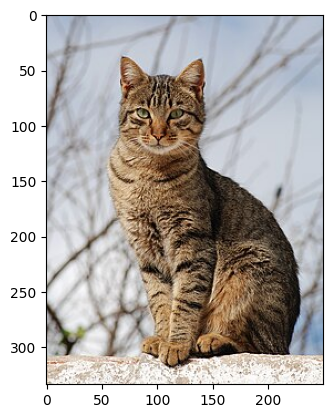

In [207]:
imagen_prueba = tf.keras.utils.load_img('gato.jpg')

imagen_prueba = tf.keras.utils.img_to_array(imagen_prueba).astype('uint8')

plt.imshow(imagen_prueba)

2026-07-10 18:06:08.434125: W tensorflow/core/kernels/data/cache_dataset_ops.cc:917] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


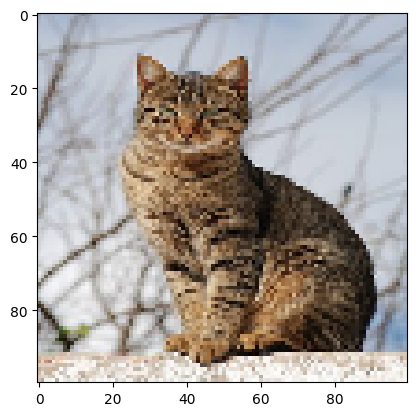

In [214]:
imagen_prueba_resize = tf.image.resize(imagen_prueba,
                                       (100,100),
                                       tf.image.ResizeMethod.BILINEAR).numpy().astype('uint8')

plt.imshow(imagen_prueba_resize)

In [218]:
imagen_prueba_resize = tf.expand_dims(imagen_prueba_resize, axis = 0)

In [228]:
pred = gatusalen.predict(imagen_prueba_resize)

pred_bin = (pred >= 0.5).astype(int)

clases[int(pred_bin)]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


'cat'

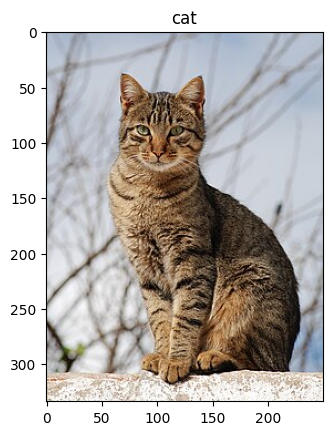

In [231]:
plt.imshow(imagen_prueba)
plt.title(clases[int(pred_bin)])

plt.show()

In [232]:
from tensorflow.keras.models import Model

outputs_dict = {
    layer.name: layer.output for layer in gatusalen.layers
}

feature_extractor = Model(
    inputs = gatusalen.inputs,
    outputs = outputs_dict
)

features = feature_extractor(imagen_prueba_resize)

In [235]:
print(features.keys())

dict_keys(['input_layer_4', 'rand_augment_4', 'rescaling_4', 'conv2d_36', 'batch_normalization_36', 'activation_36', 'conv2d_37', 'batch_normalization_37', 'activation_37', 'conv2d_38', 'batch_normalization_38', 'activation_38', 'max_pooling2d_12', 'conv2d_39', 'batch_normalization_39', 'activation_39', 'conv2d_40', 'batch_normalization_40', 'activation_40', 'conv2d_41', 'batch_normalization_41', 'activation_41', 'max_pooling2d_13', 'conv2d_42', 'batch_normalization_42', 'activation_42', 'conv2d_43', 'batch_normalization_43', 'activation_43', 'conv2d_44', 'batch_normalization_44', 'activation_44', 'max_pooling2d_14', 'global_average_pooling2d_4', 'dense_16', 'dropout_8', 'dense_17', 'dropout_9', 'dense_18', 'dense_19'])


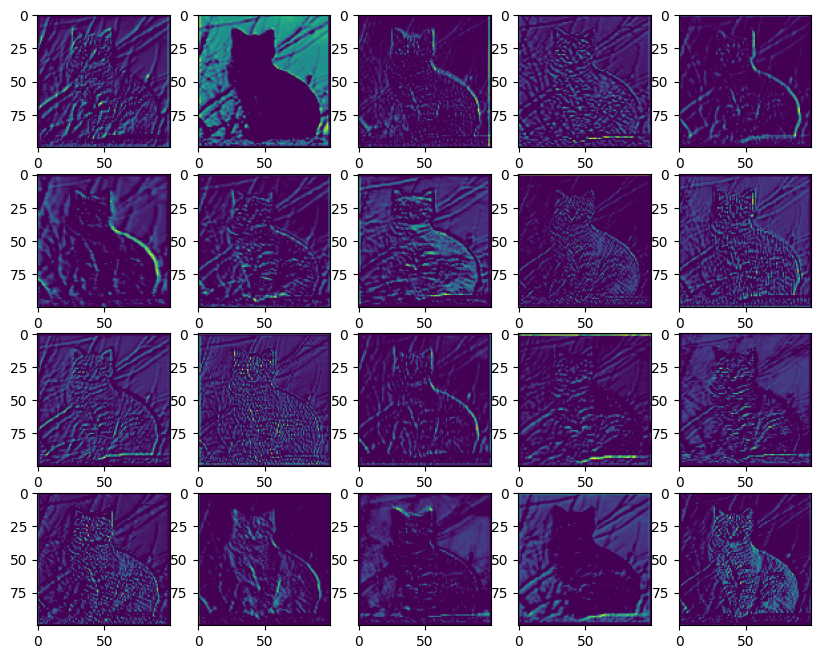

In [291]:
feature_maps = features['activation_37']

plt.figure(figsize=(10,10))

for i in range(20):
    plt.subplot(5,5,i+1)
    plt.imshow(feature_maps[0,:,:,i])

In [292]:
from tf_keras_vis.gradcam_plus_plus import GradcamPlusPlus
from tf_keras_vis.utils.model_modifiers import ReplaceToLinear
from tf_keras_vis.utils.scores import CategoricalScore
from tf_keras_vis.utils.scores import BinaryScore
import matplotlib.cm as cm


In [325]:
gradcam = GradcamPlusPlus(model = gatusalen,
                          model_modifier=ReplaceToLinear(),
                          clone = True
                          )

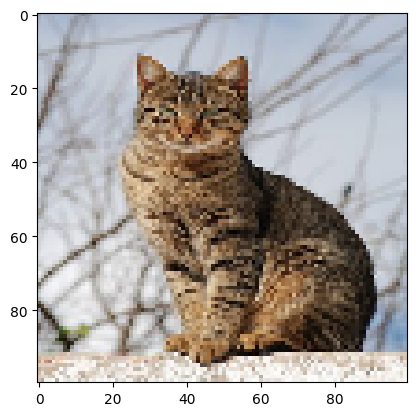

In [303]:
plt.imshow(imagen_prueba_resize[0].numpy())

In [ ]:
imag_test = (imagen_prueba_resize/255)

In [332]:
imag_test

<tf.Tensor: shape=(1, 100, 100, 3), dtype=float32, numpy=
array([[[[0.6156863 , 0.6431373 , 0.7058824 ],
         [0.6862745 , 0.7176471 , 0.78039217],
         [0.654902  , 0.69803923, 0.76862746],
         ...,
         [0.72156864, 0.7529412 , 0.81960785],
         [0.7137255 , 0.7529412 , 0.8117647 ],
         [0.7058824 , 0.7529412 , 0.80784315]],

        [[0.6509804 , 0.6784314 , 0.7411765 ],
         [0.7058824 , 0.7411765 , 0.80784315],
         [0.6745098 , 0.7137255 , 0.78431374],
         ...,
         [0.70980394, 0.75686276, 0.8156863 ],
         [0.70980394, 0.75686276, 0.81960785],
         [0.69803923, 0.7490196 , 0.8156863 ]],

        [[0.68235296, 0.7176471 , 0.78431374],
         [0.7058824 , 0.7411765 , 0.80784315],
         [0.69411767, 0.7372549 , 0.80784315],
         ...,
         [0.7019608 , 0.7529412 , 0.80784315],
         [0.7058824 , 0.7529412 , 0.8156863 ],
         [0.69803923, 0.7411765 , 0.8117647 ]],

        ...,

        [[0.8039216 , 0.7294118 , 

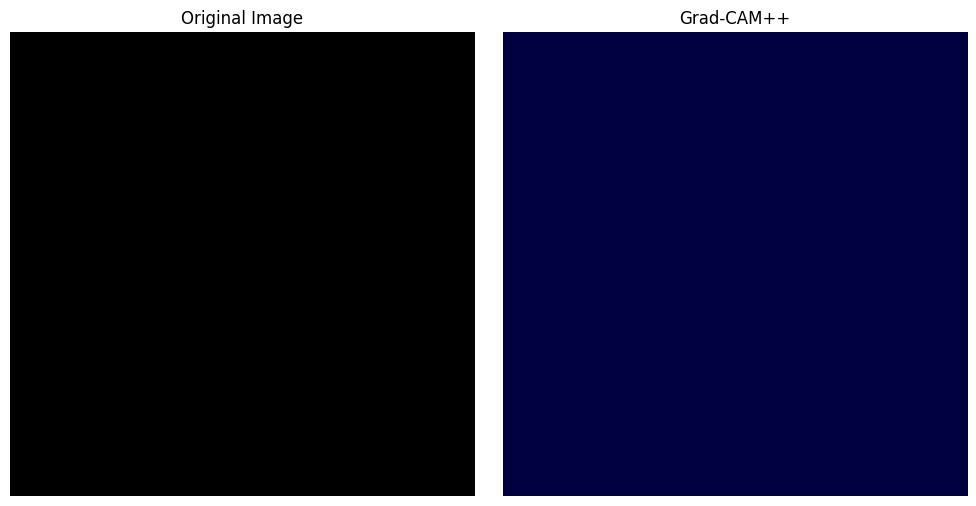

In [331]:
cam = gradcam(
    BinaryScore(1),
    imag_test,
    penultimate_layer='activation_37'
)

# Creamos figura con dos subplots (imagen original + heatmap)
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# -------------------------
# Imagen original
# -------------------------
axes[0].imshow(imag_test[0].numpy().astype(np.uint8))
axes[0].set_title('Original Image')
axes[0].axis('off')

# -------------------------
# Grad-CAM overlay
# -------------------------

# Mostramos la imagen base
axes[1].imshow(imag_test[0].numpy().astype(np.uint8))

# Convertimos el heatmap a colores (jet) y escala 0-255
heatmap = np.uint8(cm.jet(cam[0])[..., :3] * 255)

# Superponemos el heatmap sobre la imagen
axes[1].imshow(heatmap, cmap='jet', alpha=0.5)

axes[1].set_title('Grad-CAM++')
axes[1].axis('off')

# Ajuste de layout para evitar solapamientos
plt.tight_layout()
plt.show()

In [316]:
print(type(gatusalen))

for layer in gatusalen.layers[:3]:
    print(layer, type(layer))

<class 'keras.src.models.functional.Functional'>
<InputLayer name=input_layer_4, built=True> <class 'keras.src.layers.core.input_layer.InputLayer'>
<RandAugment name=rand_augment_4, built=True> <class 'keras.src.layers.preprocessing.image_preprocessing.rand_augment.RandAugment'>
<Rescaling name=rescaling_4, built=True> <class 'keras.src.layers.preprocessing.rescaling.Rescaling'>


In [317]:
print(gatusalen.inputs)
print(gatusalen.outputs)

[<KerasTensor shape=(None, 100, 100, 3), dtype=float32, sparse=False, ragged=False, name=input_layer_4>]
[<KerasTensor shape=(None, 1), dtype=float32, sparse=False, ragged=False, name=keras_tensor_407>]


In [318]:
x = tf.random.uniform((1,100,100,3))

with tf.GradientTape() as tape:
    tape.watch(x)
    y = gatusalen(x, training=False)

grad = tape.gradient(y, x)

print(grad is None)

False


In [319]:
import tf_keras_vis
print(tf_keras_vis.__version__)

0.8.7
